<div align="center" >
    <br /><br />
    <h1>Universidad de Sevilla</h1>
    <h2>Escuela Técnica Superior de Ingeniería Informática</h2>
    <h3>Grado en Ingeniería del Software</h3>
    <img src="images/logo_us.png" alt="Logo Universidad de Sevilla" width="250" />
    <br />
    <hr />
    <br />
    <h1>Extracción de características relacionales en Cora</h1>
    <h2>Construcción de variables topológicas para aprendizaje relacional</h2>
    <br />
    <hr />
    <br />
    <p><strong>Asignatura:</strong> Inteligencia Artificial</p>
    <p><strong>Grupo:</strong> Aprendizaje Automático Relacional - G5</p>
    <p><strong>Curso Académico:</strong> 2025/2026</p>
</div>

<br /><br /><br /><br />

<div align="right" >
    <p><strong>Autores:</strong><br />
    Juan Antonio Fernández Ruiz<br />
    Eulogio Reyes Díaz<br />
</div>

<div align="right" >
    <p><strong>Fecha:</strong> 7 de Junio de 2026</p>
</div>

<br /><br />

# Extracción de características relacionales

## 0. Introducción y objetivo

**Objetivo:** Construir variables relacionales a partir de la estructura del grafo Cora para complementar las características nativas de texto con información topológica.

**Enfoque metodológico:** A partir del grafo de citaciones, se calculan métricas de centralidad, clustering y comunidad para cada nodo, enriqueciendo la representación de los artículos antes del modelado supervisado.

## Indice de contenidos

- [0. Introducción y objetivo](#0-introducción-y-objetivo)
- [1. Carga de datos y reconstrucción del grafo](#1-carga-de-datos-y-reconstrucción-del-grafo)
- [2. Extracción de métricas relacionales](#2-extracción-de-métricas-relacionales)
- [3. Persistencia para tareas posteriores](#3-persistencia-para-tareas-posteriores)
- [4. Conclusiones y siguientes pasos](#4-conclusiones-y-siguientes-pasos)

In [7]:
import sys
from pathlib import Path

import pandas as pd
import networkx as nx
from networkx.algorithms import community

import seaborn as sns
import matplotlib.pyplot as plt

## 1. Carga de datos y reconstrucción del grafo

Se definen las rutas base, se cargan los archivos `.content` y `.cites`, y se construye un grafo no dirigido asegurando la consistencia entre nodos y etiquetas.

In [4]:

# Directorio base del proyecto
BASE_DIR = Path.cwd().parent

# Ruta al dataset
data_path = BASE_DIR / 'data' / 'cora'

# Ruta para guardar las figuras
figs_path = BASE_DIR / 'docs' / 'trabajo' / 'figuras'


path_cora_content = data_path / "cora.content"
path_cora_cites = data_path / "cora.cites"

# Cargar nodos, características y etiquetas
cora_content = pd.read_csv(path_cora_content, sep="\t", header=None)

paper_ids = cora_content.iloc[:, 0].astype(str)
features = cora_content.iloc[:, 1:-1]
labels = cora_content.iloc[:, -1]

df_nodes = pd.DataFrame({
    "paper_id": paper_ids,
    "label": labels
})

# Cargar citas (aristas)
cora_cites = pd.read_csv(
    path_cora_cites,
    sep="\t",
    header=None,
    names=["cited_paper_id", "citing_paper_id"]
)

cora_cites["cited_paper_id"] = cora_cites["cited_paper_id"].astype(str)
cora_cites["citing_paper_id"] = cora_cites["citing_paper_id"].astype(str)

# Construir el grafo no dirigido
G = nx.from_pandas_edgelist(
    cora_cites,
    source="cited_paper_id",
    target="citing_paper_id"
)

# Asegurar que todos los nodos de cora.content estén presentes en el grafo
G.add_nodes_from(paper_ids)

print(f"Número de nodos en el grafo: {G.number_of_nodes()}")
print(f"Número de aristas en el grafo: {G.number_of_edges()}")
print(f"Dimensión de la matriz de características: {features.shape}")
print(f"Número de clases: {labels.nunique()}")

Número de nodos en el grafo: 2708
Número de aristas en el grafo: 5278
Dimensión de la matriz de características: (2708, 1433)
Número de clases: 7


## 2. Extracción de métricas relacionales

Se calculan las siguientes propiedades para cada nodo:
* Centralidad de grado y betweenness.
* Coeficiente de clustering.
* Detección de comunidades mediante el algoritmo de Louvain.

Total de comunidades detectadas: 104


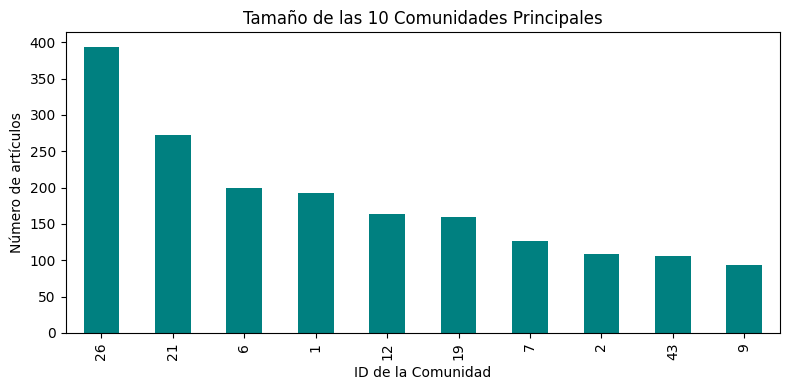

,centralidad_grado,centralidad_betweenness,coeficiente_clustering,comunidad_louvain
count,2708.000000,2708.000000,2708.000000,2708.000000
mean,0.001440,0.001653,0.240673,19.562408
std,0.001932,0.006941,0.322079,18.134217
min,0.000369,0.000000,0.000000,0.000000
25%,0.000739,0.000000,0.000000,7.000000
50%,0.001108,0.000255,0.095238,17.000000
75%,0.001847,0.001299,0.333333,26.000000
max,0.062061,0.232488,1.000000,103.000000


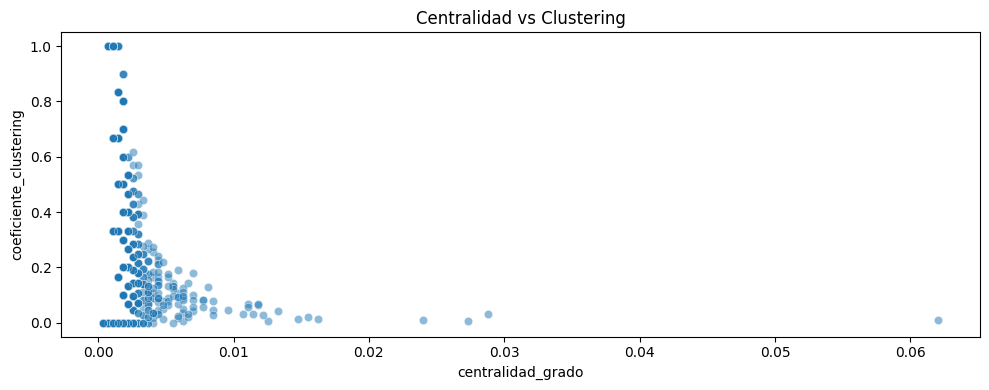

Figuras guardadas en: c:\Users\juana\aprendizaje-automatico-relacional\docs\trabajo\figuras\caracteristicas_relacionales


In [11]:
# --- 1. MÉTRICAS DE CENTRALIDAD ---
# Calculamos la centralidad de grado y la centralidad de intermediación (betweenness)
# Puedes calcular otras como nx.closeness_centrality(G) si lo deseas
dict_degree_cent = nx.degree_centrality(G)
dict_betweenness_cent = nx.betweenness_centrality(G)

# --- 2. COEFICIENTE DE CLUSTERING ---
# Mide la tendencia de los nodos a agruparse en triángulos
dict_clustering = nx.clustering(G)

# --- 3. DETECCIÓN DE COMUNIDADES ---
# El documento sugiere métodos como Louvain, Girvan-Newman o Walktrap. 
# Usaremos Louvain, que es muy eficiente y está integrado en NetworkX.
comunidades_louvain = community.louvain_communities(G)

# Convertimos la lista de comunidades en un diccionario {nodo: id_comunidad}
dict_comunidades = {}
for id_comunidad, set_nodos in enumerate(comunidades_louvain):
    for nodo in set_nodos:
        dict_comunidades[nodo] = id_comunidad

# --- 4. CONSOLIDACIÓN EN UN DATAFRAME ---
# Unimos todas las características extraídas en un DataFrame usando el ID del artículo como índice
df_relacional = pd.DataFrame({
    'centralidad_grado': pd.Series(dict_degree_cent),
    'centralidad_betweenness': pd.Series(dict_betweenness_cent),
    'coeficiente_clustering': pd.Series(dict_clustering),
    'comunidad_louvain': pd.Series(dict_comunidades)
})

# Renombramos el índice para que coincida con EDA previo
df_relacional.index.name = 'paper_id'

# Carpeta específica para las figuras de esta tarea
figs_relacionales_path = figs_path / 'caracteristicas_relacionales'
figs_relacionales_path.mkdir(parents=True, exist_ok=True)

# Contar cuántas comunidades se detectaron y su tamaño
conteo_comunidades = df_relacional['comunidad_louvain'].value_counts()
print(f"Total de comunidades detectadas: {len(conteo_comunidades)}")

# Ver el tamaño de las 10 comunidades más grandes
ax = conteo_comunidades.head(10).plot(kind='bar', figsize=(8, 4), color='teal')
plt.title("Tamaño de las 10 Comunidades Principales")
plt.ylabel("Número de artículos")
plt.xlabel("ID de la Comunidad")
fig_top10 = ax.get_figure()
fig_top10.tight_layout()
fig_top10.savefig(figs_relacionales_path / 'top10_comunidades_louvain.png', dpi=300, bbox_inches='tight')
plt.show()

# Mostramos los primeros 5 nodos con sus nuevas características relacionales
df_relacional.head()

# Resumen estadístico rápido
display(df_relacional.describe())

# Ver la relación entre las métricas
plt.figure(figsize=(10, 4))
sns.scatterplot(data=df_relacional, x='centralidad_grado', y='coeficiente_clustering', alpha=0.5)
plt.title("Centralidad vs Clustering")
plt.tight_layout()
plt.savefig(figs_relacionales_path / 'centralidad_vs_clustering.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Figuras guardadas en: {figs_relacionales_path}")

### Análisis de las Métricas Relacionales

A la vista de las estadísticas descriptivas y las visualizaciones, podemos extraer tres conclusiones fundamentales sobre la topología del dataset Cora:

**1. Fragmentación en Sub-nichos (Comunidades de Louvain)**
* Aunque el dataset original clasifica los artículos en 7 grandes categorías, la topología pura del grafo (detectada por Louvain) revela **104 comunidades** (valor máximo de 103). 
* No obstante, el gráfico de barras demuestra que la distribución es muy desigual: las 10 comunidades principales dominan la red agrupando a la mayoría de los artículos (la comunidad 19 lidera con casi 300 *papers*). Esto sugiere que las grandes disciplinas del Machine Learning se dividen de forma natural en sub-nichos de investigación muy compactos y definidos por sus citas.

**2. La Paradoja de los Hubs (Centralidad vs Clustering)**
* El gráfico de dispersión muestra una clara distribución en forma de "L". Esto indica que **los artículos más citados (alta centralidad) tienen un coeficiente de clustering muy bajo**. Al ser "hubs" súper-influyentes, son citados por investigadores de ramas muy diversas que no interactúan entre sí, lo que impide la formación de redes cerradas (triángulos).
* Por el contrario, los únicos nodos que alcanzan un clustering perfecto (1.0) son aquellos con una centralidad mínima. Esto representa a pequeños grupos de investigadores trabajando en temas muy específicos que se citan exclusivamente entre ellos.

**3. Artículos "Puente" (Centralidad de Betweenness)**
* La tabla descriptiva muestra una asimetría extrema en la intermediación. Mientras que la mediana es prácticamente nula (0.0002), el valor máximo se dispara (0.232). Esto confirma que la gran mayoría de los artículos operan en la periferia de su área, pero existe un grupo minúsculo de *papers* interdisciplinares que actúan como puentes estructurales y mantienen unida toda la red científica.

## 3. Persistencia para tareas posteriores

El dataframe resultante se consolida y exporta para su uso en el análisis de correlaciones (Tarea 1.5) y entrenamiento de modelos (Tarea 2.1).

In [9]:
# Guardamos CSV consolidado para reutilizar en las siguientes tareas
df_completo = features.copy()
df_completo.columns = [f"word_{i}" for i in range(df_completo.shape[1])]

df_completo.insert(0, "paper_id", paper_ids.values)

df_completo = df_completo.merge(
    df_relacional.reset_index(),
    on="paper_id",
    how="left"
)

# 1. Verificar que no perdimos filas
assert df_completo.shape[0] == features.shape[0], "¡Alerta! El número de filas cambió tras el merge."

# 2. Verificar que no hay valores nulos generados por el cruce
nulos_generados = df_completo[['centralidad_grado', 'comunidad_louvain']].isnull().sum()
print("Valores nulos en las nuevas columnas tras el merge:")
print(nulos_generados)

df_completo["class_label"] = labels.values

output_path = BASE_DIR / "data" / "cora_features_completas.csv"
df_completo.to_csv(output_path, index=False)

print(f"CSV guardado en: {output_path}")
print(df_completo.shape)

Valores nulos en las nuevas columnas tras el merge:
centralidad_grado    0
comunidad_louvain    0
dtype: int64
CSV guardado en: c:\Users\juana\aprendizaje-automatico-relacional\data\cora_features_completas.csv
(2708, 1439)


## 4. Conclusiones y siguientes pasos

- Las metricas relacionales quedan consolidadas y alineadas por nodo para su uso inmediato.
- Esta salida habilita el analisis de correlaciones en Tarea 1.5 y la construccion de modelos en Tarea 2.1.
- La persistencia en archivo evita recomputar el grafo en notebooks posteriores.